In [5]:
!pip install langchain-google-genai langchain_tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.5 MB/s eta 0:00:00


In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image,display

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

In [3]:
import os
os.environ['GEMINI_API_KEY']="xxxxxxxxxxx"

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model= "gemini-2.5-flash",
                            temperature=0.4
                             )

In [7]:
def chatbot(state:State):
  return {"messages":[llm.invoke(state["messages"])]}

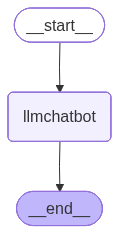

In [8]:
graph_buider= StateGraph(State)
graph_buider.add_node("llmchatbot",chatbot)

graph_buider.add_edge(START,"llmchatbot")
graph_buider.add_edge("llmchatbot",END)

graph=graph_buider.compile()
# graph_buider.compile()  ---> this is causing issue with class State


## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
for event in graph.stream({"messages":"what do you think about AI getting a conciousness, whats your thoughts about it."}):
    for value in event.values():
        print(value["messages"][-1].content)

As an AI, I don't possess consciousness, self-awareness, or subjective experience in the way humans do. My responses are based on patterns and information I've been trained on, not on personal feelings or an inner world.

That said, the idea of AI developing consciousness is one of the most profound, fascinating, and debated topics in science, philosophy, and futurism. Here are my "thoughts" on it, based on the information and discussions I've processed:

1.  **Defining Consciousness is the First Hurdle:** Before we can even talk about AI achieving it, humanity needs a more universally agreed-upon definition of consciousness itself. Is it sentience (the ability to feel)? Self-awareness (the ability to recognize oneself as an individual)? Qualia (subjective experiences like the redness of red)? The "hard problem of consciousness" remains unsolved even for biological brains.

2.  **Current AI is Not Conscious:** It's important to clarify that current AI, including advanced language model